In [1]:
import time
start_time=time.time()

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from spectral_cube import SpectralCube
from turbustat.simulator import make_ppv
from pathlib import Path
import astropy.units as u
from astropy.io import fits
from matplotlib import pyplot as plt
from skimage.util import random_noise

# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root
from turb_utils import make_extended, make_3dfield

C:\Users\javas\anaconda3\envs\viento\Lib\site-packages\turbustat\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [3]:
line        = "NaN"
lambda_rest = 0
line_id     = "NaN"
line_id2    = "NaN"
line

'NaN'

In [4]:
# Binning
bins        = 0

# Fake data
region     = 'Synthetic 3D map'
name_reg   = 'Synthetic 3D map'
reg_id     = 'Synthetic 3D map'
inst       = 'NaN'
inst_id    = 'NaN'
type_obj   = 'NaN'

# Physical parameters
pix        = 1  # Instrument resolution [arcsec/pix]
dist       = 1 # Distance [parsecs]
s0_        = 0.0    # proposed seeing
pc         = 1
#pc         = dist*(2*np.pi) / (360 * 60 * 60) # value in parsecs of each arcsec
s0         = 0
#s0         = (s0_*pc) / 2.355    # RMS seeing [parsecs]
noise      = 0

# Fake map parameters
N             = 256
ra            = N / 16 # Artificial correlation length 
#sig_E         = 0 
sig_E         = 1 
#sig_E         = 2 
ellip         = 0.5
theta         = 45
amp           = 1.0
randomseed_vv = 1894_04_25
randomseed_sb = 1939_05_01

# Fake obs parameters
s0    = 0
noise = 0
pc    = 1
pix   = 1
line  = 'NaN'

if sig_E == 0:
    m3D           = 0.0   # for recovering m as 1.00 in the projected field (k = 3D + m3D) non-fluctuations sigE = 0
elif sig_E == 1:
    m3D           = 0.30  # for recovering m as 1.00 in the projected field (k = 3D + m3D) light fluctuations sigE = 1
elif sig_E == 2:
    m3D           = 0.55  # for recovering m as 1.00 in the projected field (k = 3D + m3D) heavy fluctuations sigE = 2

print(m3D)

0.3


In [5]:
name      = 'fake_cube_mod_finite_'+'sigE' + str(int(sig_E)) +'_m' +str(int((3+m3D)*100))+'_r' +str(int(ra))+ '_N' + str(N) + '_' + 'bin' + str(bins)
name_id   = name
name_file = name
print(name)

fake_cube_mod_finite_sigE1_m330_r16_N256_bin0


In [6]:
## Emissivity fluctuations test I

density = make_3dfield(N, 
    powerlaw            = 3.0 + m3D, 
    correlation_length  = ra,  
    amp                 = amp,
    ellip               = ellip,
    theta               = theta,
    randomseed          = randomseed_sb) * u.cm**-3 

density = (density-density.mean())/density.std()

emissivity = np.exp(sig_E * density) * u.cm**-3 # Check this!!


In [7]:
# Velocity fluctuations

velocity = make_3dfield(N,
    powerlaw            = 3.0 + m3D,
    correlation_length  = ra,  
    amp                 = amp,
    ellip               = ellip,
    theta               = theta,
    randomseed          = randomseed_vv)* u.km / u.s   


In [8]:
# Making PPV cube

cube_hdu = make_ppv(velocity, emissivity, los_axis=0,
                    T=10000 * u.K, chan_width=0.5 * u.km / u.s,
                    v_min=-20 * u.km / u.s,
                    v_max=20 * u.km / u.s)  

cube = SpectralCube.read(cube_hdu)  

In [9]:
sb = cube.moment0().value
vv = cube.moment1().value

sig = vv.std()
vv /= sig

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_48792\126694012.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 0, 'pix')

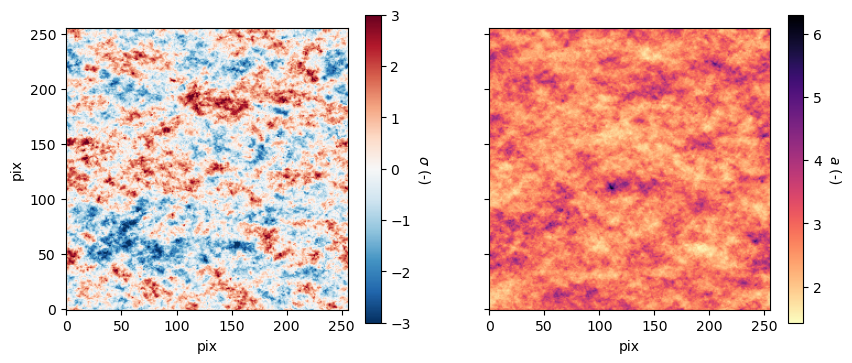

In [10]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma_r")
im = ax.imshow(vv, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

ax.set_xlabel("pix")
ax.set_ylabel("pix")
axx.set_xlabel("pix")

#ax.set_title("3D Tapered")
#axx.set_title("3D Non Tapered")


In [11]:
primary = fits.PrimaryHDU()
primary.header["FILE"]       = (name_file, "Fits file name")
primary.header["NAME_ID"]    = (name_id, "pipeline identifier")
primary.header["REG"]        = (region, "Region catalog name")
primary.header["NAME_REG"]   = (name_reg, "Region name")
primary.header["REG_ID"]     = (reg_id, "Region identifier")
primary.header["TYPE_OBJ"]   = (type_obj, "Type object")
primary.header["DIST"]       = (dist, "Distance in parsecs")
primary.header["INSTR"]      = (inst, "Instrument")
primary.header["LINE"]       = (line, "Emission line name")
primary.header["LINE_ID"]    = (line_id, "Emission line identifier")
primary.header["L_REST"]     = (lambda_rest, "Emission line name")
primary.header["SIG"]        = (sig, "Standard deviation vel map")
primary.header["SIG2"]       = (sig**2, "Vel Variance map")
primary.header["S0"]         = (s0, "Atmospheric seeing")
primary.header["BOX_SIZE"]   = (N, "Observational box_size")
primary.header["PC"]         = (pc* (2**bins), "parsec convertion")
primary.header["PIX"]        = (pix, "Instrument pixel scale")
primary.header["BINSIZE"]    = (bins, "Spatial binning factor")
primary.header["noise"]      = (noise, "Instrumental noise")
#primary.header["m2D"]       = (m2D, "k = 3 + m3D")
primary.header["m3D"]        = (m3D, "k = 3 + m3D")
primary.header["ra"]         = (ra, "Artificial correlation length")
primary.header["SEED1"]      = (randomseed_vv, "Random seed velocity")
primary.header["SEED2"]      = (randomseed_sb, "Random seed surfavebrightness")
primary.header["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")

In [12]:
hdu_m0 = fits.ImageHDU(data=sb,  name='MOM0')
hdu_m1 = fits.ImageHDU(data=vv,  name='MOM1')
#hdu_m2 = fits.ImageHDU(data=ss_m[trim],  name='MOM2')
#hdu_mk = fits.ImageHDU(data=good.astype(np.uint8) ,  name='MASK')

In [13]:
hdul = fits.HDUList([primary, hdu_m0, hdu_m1])
hdul.writeto('fits_ready/' + name_id + '.fits', overwrite=True)

In [14]:
with fits.open("fits_ready/" + name_id + ".fits") as hdul:
    hdul.info()
    
hdr = hdul[0].header
print(hdr)

Filename: fits_ready/fake_cube_mod_finite_sigE1_m330_r16_N256_bin0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      28   ()      
  1  MOM0          1 ImageHDU         8   (256, 256)   float64   
  2  MOM1          1 ImageHDU         8   (256, 256)   float64   
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  FILE    = 'fake_cube_mod_finite_sigE1_m330_r16_N256_bin0' / Fits file name      NAME_ID = 'fake_cube_mod_finite_sigE1_m330_r16_N256_bin0' / pipeline identifier REG     = 'Synthetic 3D map'   / Region catalog name                            NAME_REG= 'Synthetic 3D map'   / Region name                                    REG_ID  = 'Synthetic 3D map'   / Region ide

In [15]:
print("--- %s seconds ---" % (time.time()-start_time))

--- 227.06987738609314 seconds ---
